# Assignment 2: Classification and Regression

**Total Marks:** 10  
**Level:** Intermediate  
**Topics:** Training, hyperparameter tuning, and evaluation of classification and regression algorithms

---

## Instructions

This assignment contains two parts:
1. **Part A: Classification on Unbalanced Data (5 marks)**
2. **Part B: Regression Models (5 marks)**

**Important:**
- Datasets are pre-generated and provided for you
- Store results in the **exact variable names** specified in each task
- Execute all cells before submission
- Otter-Grader will automatically test your outputs

---

## Setup: Imports and Dataset Generation

In [80]:
from functools import partial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import TransformedTargetRegressor
import warnings
from IPython.display import display
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


---

# PART A: CLASSIFICATION ON UNBALANCED DATA (5 Marks)

---

## Classification - Data Preparation (PROVIDED)

In [81]:
# Generate unbalanced classification dataset (90-10 class imbalance)
X_class, y_class = make_classification(n_samples=1000, n_features=20, n_informative=15,
                                       n_redundant=5, weights=[0.9, 0.1], random_state=42)

# Split data with stratification 80:20
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(X_class, y_class)

# Standardize features
scaler_class = StandardScaler()            
X_class_train_scaled = scaler_class.fit_transform(X_class_train)
X_class_test_scaled = scaler_class.transform(X_class_test)

print("Classification Dataset:")
print(f"Training samples: {X_class_train_scaled.shape[0]}, Testing samples: {X_class_test_scaled.shape[0]}")
print(f"Features: {X_class_train_scaled.shape[1]}")
print(f"Class distribution (train): {np.bincount(y_class_train)}")
print(f"Class imbalance ratio: {np.bincount(y_class)[0] / np.bincount(y_class)[1]:.2f}:1")

Classification Dataset:
Training samples: 750, Testing samples: 250
Features: 20
Class distribution (train): [676  74]
Class imbalance ratio: 8.80:1


## Classification - Task 1: Baseline Models (1.5 Marks)

Train 5 classification models with default hyperparameters:
1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. Support Vector Machine (SVM)
5. Gaussian Naive Bayes

**Expected Output Variable: `classification_baseline_results`**
- Create a pandas DataFrame with:
  - Index: Model names
  - Columns: "Accuracy", "ROC-AUC"
  - Values: Metrics calculated on test set

In [82]:
# BEGIN QUESTION
# name: classification_baseline_models
# points: 1.5

# Train 5 baseline classification models
# Store results in DataFrame: classification_baseline_results
# Columns: "Accuracy", "ROC-AUC"
# Index: Model names

# NOTE: set probability=True for SVC() as by default it doesn't enable probability calculation (i.e. .predict_probab() cannot be called if not set)
model_classes = [LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, partial(SVC, probability=True), GaussianNB]
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'Gaussian Naive Bayes']

metrics = []
for model_cls in model_classes:
    model = model_cls().fit(X_class_train_scaled, y_class_train)
    ypred = model.predict(X_class_test_scaled)
    metrics.append({
        'Accuracy': accuracy_score(y_class_test, ypred),
        'ROC-AUC': roc_auc_score(y_class_test, ypred)
    })
classification_baseline_results = pd.DataFrame(metrics, index=model_names)

print("Classification Baseline Model Performance:")
classification_baseline_results

# END QUESTION

Classification Baseline Model Performance:


,Accuracy,ROC-AUC
Logistic Regression,0.900,0.569176
Decision Tree,0.880,0.667149
Random Forest,0.896,0.535714
SVM,0.924,0.660714
Gaussian Naive Bayes,0.912,0.622748


In [83]:
# BEGIN TESTS
assert classification_baseline_results is not None, "classification_baseline_results not created"
assert isinstance(classification_baseline_results, pd.DataFrame), "Must be a DataFrame"
assert classification_baseline_results.shape[0] == 5, "Must have 5 models"
assert classification_baseline_results.shape[1] == 2, "Must have 2 columns"
assert "Accuracy" in classification_baseline_results.columns
assert "ROC-AUC" in classification_baseline_results.columns
assert classification_baseline_results["Accuracy"].between(0,1).all()
assert classification_baseline_results["ROC-AUC"].between(0,1).all()
# END TESTS

## Classification - Task 2: Hyperparameter Tuning (2.5 Marks)

Use GridSearchCV to tune hyperparameters for all 5 classification algorithms.

**Hyperparameter Grids:**
- **Logistic Regression:** `{'C': [0.01, 0.1, 1, 10], 'class_weight': [None, 'balanced']}`
- **Decision Tree:** `{'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10], 'class_weight': [None, 'balanced']}`
- **Random Forest:** `{'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'class_weight': [None, 'balanced']}`
- **SVM:** `{'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'class_weight': [None, 'balanced']}`
- **Naive Bayes:** `{'var_smoothing': [1e-9, 1e-8, 1e-7]}`

**Expected Output Variables:**
- `classification_tuned_models` (dict): Keys = model names, Values = best fitted models
- `classification_tuning_results` (dict): Keys = model names, Values = best hyperparameters

In [84]:
# BEGIN QUESTION
# name: classification_hyperparameter_tuning
# points: 2.5

# Tune hyperparameters for all 5 classification algorithms
# Use GridSearchCV with cv=5, scoring='roc_auc'
# Store tuned models in: classification_tuned_models
# Store best params in: classification_tuning_results

classification_tuned_models = {}  # Dict with tuned models
classification_tuning_results = {}  # Dict with best parameters

param_grids = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10], 'class_weight': [None, 'balanced']},
    'Decision Tree': {'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10], 'class_weight': [None, 'balanced']},
    'Random Forest': {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'class_weight': [None, 'balanced']},
    'SVM': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'class_weight': [None, 'balanced']},
    'Gaussian Naive Bayes': {'var_smoothing': [1e-9, 1e-8, 1e-7]}
}

for name, model_cls in zip(model_names, model_classes):
    clf = GridSearchCV(model_cls(), param_grids[name], cv=5, scoring='roc_auc', verbose=1).fit(X_class_train_scaled, y_class_train)
    #print(f'{name}: Cross-Validation results of GridSearchCV: {clf.cv_results_}')
    print(f'{name}: Score of best estimator: {clf.best_score_}')
    classification_tuned_models[name] = clf.best_estimator_
    classification_tuning_results[name] = clf.best_params_

print("Best Hyperparameters Found:")
for model_name, params in classification_tuning_results.items():
    print(f"{model_name}: {params}")

# END QUESTION

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Logistic Regression: Score of best estimator: 0.8683940761489781
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Decision Tree: Score of best estimator: 0.7259059549745824
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Random Forest: Score of best estimator: 0.9393713300134868
Fitting 5 folds for each of 12 candidates, totalling 60 fits
SVM: Score of best estimator: 0.9587622159975101
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Gaussian Naive Bayes: Score of best estimator: 0.8679227616972716
Best Hyperparameters Found:
Logistic Regression: {'C': 0.1, 'class_weight': 'balanced'}
Decision Tree: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 2}
Random Forest: {'class_weight': 'balanced', 'max_depth': 20, 'n_estimators': 200}
SVM: {'C': 1, 'class_weight': None, 'kernel': 'rbf'}
Gaussian Naive Bayes: {'var_smoothing': 1e-09}


In [85]:
# BEGIN TESTS
assert isinstance(classification_tuned_models, dict), "Must be a dictionary"
assert isinstance(classification_tuning_results, dict), "Must be a dictionary"
assert len(classification_tuned_models) == 5, "Must have 5 models"
assert len(classification_tuning_results) == 5, "Must have 5 entries"
# END TESTS

## Classification - Task 3: Evaluation & Comparison (1.0 Mark)

Evaluate all tuned models and create visualizations.

**Expected Output Variables:**
- `classification_final_results` (DataFrame): Model names × ["Accuracy", "ROC-AUC"], sorted by ROC-AUC
- `classification_roc_plot` (figure): ROC curves for all 5 models

In [86]:
# BEGIN QUESTION
# name: classification_evaluation_table
# points: 0.5

# Evaluate all tuned models on test set
# Create DataFrame: classification_final_results
# Sort by ROC-AUC in descending order

metrics = []
for name in model_names:
    ypred = classification_tuned_models[name].predict(X_class_test_scaled)
    metrics.append({
        'Accuracy': accuracy_score(y_class_test, ypred),
        'ROC-AUC': roc_auc_score(y_class_test, ypred)
    })
classification_final_results = pd.DataFrame(metrics, index=model_names).sort_values('ROC-AUC', ascending=False)

print("Classification Final Model Performance:")
display(classification_final_results)
print(f"\nBest Model: {classification_final_results.index[0]} with ROC-AUC = {classification_final_results.iloc[0]['ROC-AUC']:.4f}")

# END QUESTION

Classification Final Model Performance:


,Accuracy,ROC-AUC
Logistic Regression,0.824,0.760457
Decision Tree,0.768,0.682111
SVM,0.924,0.660714
Gaussian Naive Bayes,0.912,0.622748
Random Forest,0.892,0.517857



Best Model: Logistic Regression with ROC-AUC = 0.7605


In [87]:
# BEGIN TESTS
assert classification_final_results is not None
assert isinstance(classification_final_results, pd.DataFrame)
assert classification_final_results.shape[0] == 5
assert classification_final_results.shape[1] == 2
assert "Accuracy" in classification_final_results.columns
assert "ROC-AUC" in classification_final_results.columns
# END TESTS

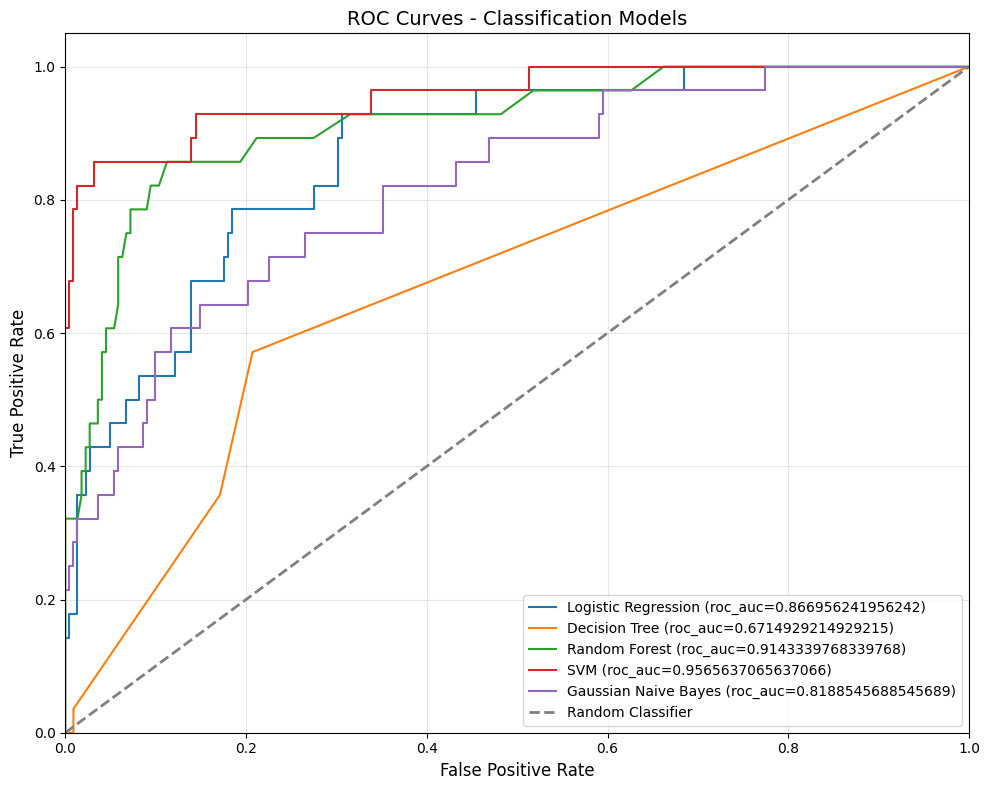

In [88]:
# BEGIN QUESTION
# name: classification_roc_curves
# points: 0.5

# Plot ROC curves for all 5 tuned models
# Store figure in: classification_roc_plot

classification_roc_plot = plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Your code here to plot ROC curves
# For each model:
#   - Get probability predictions
#   - Calculate FPR, TPR using roc_curve()
#   - Calculate AUC and plot

for name in model_names:
    y_probabs = classification_tuned_models[name].predict_proba(X_class_test_scaled)
    y_preds = y_probabs[:,1]
    #y_preds = classification_tuned_models[name].predict(X_class_test_scaled)
    fpr, tpr, thresholds = roc_curve(y_class_test, y_preds)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} ({roc_auc=})')

# Plot random classifier baseline
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Classification Models', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# END QUESTION

In [89]:
# BEGIN TESTS
assert classification_roc_plot is not None
# END TESTS

---

# PART B: REGRESSION MODELS (5 Marks)

---

## Regression - Data Preparation (PROVIDED)

In [90]:
# Generate regression dataset
X_reg, y_reg = make_regression(n_samples=500, n_features=10, n_informative=8,
                               noise=20, random_state=42)

# Split data
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg)

# Standardize features
scaler_reg = StandardScaler()
X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train, y_reg_train)
X_reg_test_scaled = scaler_reg.transform(X_reg_test)

print("Regression Dataset:")
print(f"Training samples: {X_reg_train_scaled.shape[0]}, Testing samples: {X_reg_test_scaled.shape[0]}")
print(f"Features: {X_reg_train_scaled.shape[1]}")
print(f"Target range: [{y_reg.min():.2f}, {y_reg.max():.2f}]")

Regression Dataset:
Training samples: 375, Testing samples: 125
Features: 10
Target range: [-405.84, 478.39]


## Regression - Task 1: Baseline Models (1.5 Marks)

Train 5 regression models with default hyperparameters:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Polynomial Regression (degree=2)
5. Logarithmic Regression

**Expected Output Variable: `regression_baseline_results`**
- Create a pandas DataFrame with:
  - Index: Model names
  - Columns: "MSE", "R² Score"
  - Values: Metrics calculated on test set

In [101]:
# BEGIN QUESTION
# name: regression_baseline_models
# points: 1.5

# Train 5 baseline regression models
# Store results in DataFrame: regression_baseline_results
# Columns: "MSE", "R² Score"
# Index: Model names

# Hints:
# - Linear Regression: LinearRegression()
# - Ridge: Ridge()
# - Lasso: Lasso()
# - Polynomial: Use PolynomialFeatures(degree=2) then LinearRegression()
# - Logarithmic: Use np.log1p() transformation on features
# - Metrics: mean_squared_error(), r2_score()

model_names = ['Linear Regression', 'Ridge', 'Lasso', 'Polynomial', 'Logarithmic']
model_classes = [
    LinearRegression, 
    Ridge, 
    Lasso, 
    lambda: Pipeline([('polynomialfeatures', PolynomialFeatures(degree=2)), ('linreg', LinearRegression())]), 
    # NOTE: clip(x, -0.99, None) before log1p to avoid it outputting None (if no min), or infinity (if x=-1)
    #lambda: Pipeline([('log', FunctionTransformer(lambda x: np.log1p(np.clip(x,-0.99,None)))), ('ridge', Ridge())])
    lambda: Pipeline([('log', FunctionTransformer(lambda x: np.log1p(x + 3.3))), ('ridge', Ridge())])     # because min(X_reg) is about -3.24
    #lambda: TransformedTargetRegressor(Ridge(), func=np.log1p ,inverse_func=np.expm1)      # NOTE: np.log1p(x) = ln(1+x), np.expm1(y) = exp(y-1)
]

metrics = []
for name, model_cls in zip(model_names, model_classes):
    model = model_cls().fit(X_reg_train_scaled, y_reg_train)
    y_pred = model.predict(X_reg_test_scaled)
    metrics.append({
        'MSE': mean_squared_error(y_reg_test, y_pred),
        'R2 Score': r2_score(y_reg_test, y_pred)
    })
regression_baseline_results = pd.DataFrame(metrics, index=model_names)

print("Regression Baseline Model Performance:")
regression_baseline_results

# END QUESTION

Regression Baseline Model Performance:


,MSE,R2 Score
Linear Regression,328.570786,0.983096
Ridge,327.896219,0.983131
Lasso,320.039653,0.983535
Polynomial,426.374491,0.978064
Logarithmic,1010.388479,0.948018


In [102]:
# BEGIN TESTS
assert regression_baseline_results is not None
assert isinstance(regression_baseline_results, pd.DataFrame)
assert regression_baseline_results.shape[0] == 5, "Must have 5 models"
assert regression_baseline_results.shape[1] == 2, "Must have 2 columns"
assert "MSE" in regression_baseline_results.columns
assert "R2 Score" in regression_baseline_results.columns
# END TESTS

## Regression - Task 2: Hyperparameter Tuning (2.5 Marks)

Use GridSearchCV to tune hyperparameters for all 5 regression algorithms.

**Hyperparameter Grids:**
- **Linear Regression:** `{'fit_intercept': [True, False]}`
- **Ridge:** `{'alpha': [0.001, 0.01, 0.1, 1, 10]}`
- **Lasso:** `{'alpha': [0.001, 0.01, 0.1, 1, 10]}`
- **Polynomial:** `{'polynomialfeatures__degree': [1, 2, 3, 4]}`
- **Logarithmic:** `{'alpha': [0.001, 0.01, 0.1, 1]}`

**Expected Output Variables:**
- `regression_tuned_models` (dict): Keys = model names, Values = best fitted models
- `regression_tuning_results` (dict): Keys = model names, Values = best hyperparameters

In [103]:
# BEGIN QUESTION
# name: regression_hyperparameter_tuning
# points: 2.5

# Tune hyperparameters for all 5 regression algorithms
# Use GridSearchCV with cv=5, scoring='r2'
# Store tuned models in: regression_tuned_models
# Store best params in: regression_tuning_results

regression_tuned_models = {}  # Dict with tuned models
regression_tuning_results = {}  # Dict with best parameters

param_grids = {
    'Linear Regression': {'fit_intercept': [True, False]},
    'Ridge': {'alpha': [0.001, 0.01, 0.1, 1, 10]},
    'Lasso': {'alpha': [0.001, 0.01, 0.1, 1, 10]},
    'Polynomial': {'polynomialfeatures__degree': [1, 2, 3, 4]},    # NOTE: syntax 
    'Logarithmic': {'ridge__alpha': [0.001, 0.01, 0.1, 1]}
}
for name, model_cls in zip(model_names, model_classes):
    reg = GridSearchCV(model_cls(), param_grids[name], cv=5, scoring='r2', verbose=1).fit(X_reg_train_scaled, y_reg_train)
    print(f'{name}: Score of best estimator: {reg.best_score_}')
    regression_tuned_models[name] = reg.best_estimator_
    regression_tuning_results[name] = reg.best_params_

print("Best Hyperparameters Found:")
for model_name, params in regression_tuning_results.items():
    print(f"{model_name}: {params}")

# END QUESTION

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Linear Regression: Score of best estimator: 0.977347283880716
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Ridge: Score of best estimator: 0.9773481894331055
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Lasso: Score of best estimator: 0.9773478864660456
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Polynomial: Score of best estimator: 0.977347283880716
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Logarithmic: Score of best estimator: 0.9335263396655501
Best Hyperparameters Found:
Linear Regression: {'fit_intercept': True}
Ridge: {'alpha': 0.1}
Lasso: {'alpha': 0.01}
Polynomial: {'polynomialfeatures__degree': 1}
Logarithmic: {'ridge__alpha': 0.1}


In [104]:
# BEGIN TESTS
assert isinstance(regression_tuned_models, dict)
assert isinstance(regression_tuning_results, dict)
assert len(regression_tuned_models) == 5, "Must have 5 models"
assert len(regression_tuning_results) == 5, "Must have 5 entries"
# END TESTS

## Regression - Task 3: Evaluation & Comparison (1.0 Mark)

Evaluate all tuned models and create visualizations.

**Expected Output Variables:**
- `regression_final_results` (DataFrame): Model names × ["MSE", "R² Score"], sorted by R² Score
- `regression_comparison_plot` (figure): Comparison plot of model performance

In [109]:
# BEGIN QUESTION
# name: regression_evaluation_table
# points: 0.5

# Evaluate all tuned models on test set
# Create DataFrame: regression_final_results
# Sort by R² Score in descending order

metrics = []
for name in model_names:
    ypred = regression_tuned_models[name].predict(X_reg_test_scaled)
    metrics.append({
        'MSE': mean_squared_error(y_reg_test, ypred),
        'R2 Score': r2_score(y_reg_test, ypred)
    })
regression_final_results = pd.DataFrame(metrics, index=model_names).sort_values('R2 Score', ascending=False)

print("Regression Final Model Performance:")
display(regression_final_results)
print(f"\nBest Model: {regression_final_results.index[0]} with R^2 Score = {regression_final_results.iloc[0]['R2 Score']:.4f}")

# END QUESTION

Regression Final Model Performance:


,MSE,R2 Score
Lasso,328.398606,0.983105
Ridge,328.489333,0.983100
Polynomial,328.570786,0.983096
Linear Regression,328.570786,0.983096
Logarithmic,994.713541,0.948824



Best Model: Lasso with R^2 Score = 0.9831


In [106]:
# BEGIN TESTS
assert regression_final_results is not None
assert isinstance(regression_final_results, pd.DataFrame)
assert regression_final_results.shape[0] == 5
assert regression_final_results.shape[1] == 2
assert "MSE" in regression_final_results.columns
assert "R2 Score" in regression_final_results.columns
# END TESTS

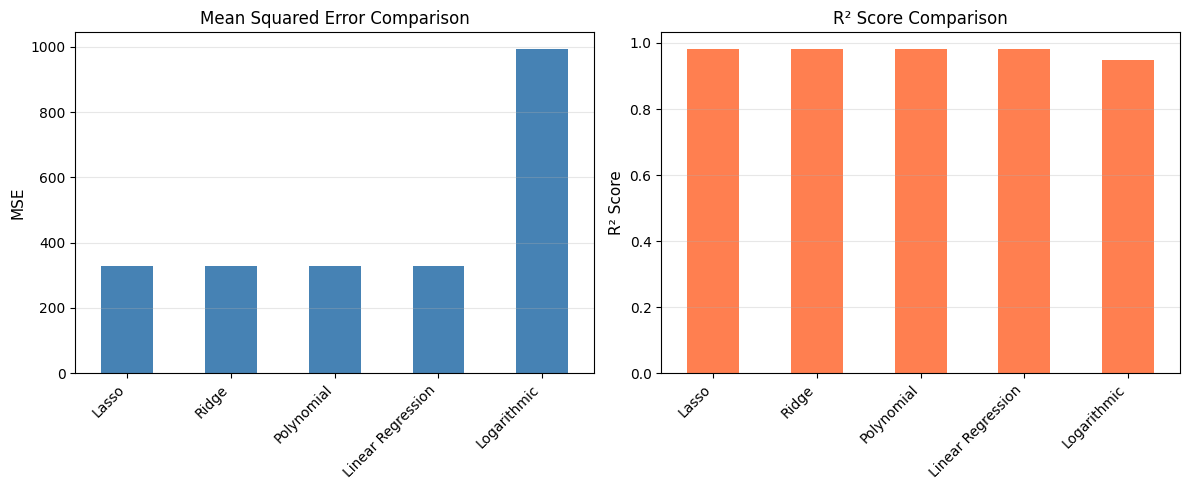

In [107]:
# BEGIN QUESTION
# name: regression_comparison_plot
# points: 0.5

# Create a comparison plot for regression models
# Store figure in: regression_comparison_plot

regression_comparison_plot = plt.figure(figsize=(12, 5))

# Subplot 1: MSE Comparison
plt.subplot(1, 2, 1)
regression_final_results['MSE'].plot(kind='bar', color='steelblue')
plt.title('Mean Squared Error Comparison', fontsize=12)
plt.ylabel('MSE', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')

# Subplot 2: R² Score Comparison
plt.subplot(1, 2, 2)
regression_final_results['R2 Score'].plot(kind='bar', color='coral')
plt.title('R² Score Comparison', fontsize=12)
plt.ylabel('R² Score', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()

# END QUESTION

In [108]:
# BEGIN TESTS
assert regression_comparison_plot is not None
# END TESTS

---

## Summary

You have completed the assignment covering:

### Part A: Classification (5 marks)
- Trained 5 classification models on unbalanced data
- Tuned hyperparameters for all 5 models
- Evaluated and compared using Accuracy and ROC-AUC

### Part B: Regression (5 marks)
- Trained 5 regression models
- Tuned hyperparameters for all 5 models
- Evaluated and compared using MSE and R² Score

**Total Marks: 10 / 10**